In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load Data and Define Targets (X, y)
# Load the dataset
df = pd.read_csv("cleaned_data.csv")

# Define Regression Target (y_reg)
y_reg = df['Exam_Score']

# Define Classification Target (y_clf) based on Median
median_score = y_reg.median()
y_clf = (y_reg > median_score).astype(int)

# Define Feature Matrix (X) by dropping target column
X = df.drop(columns=['Exam_Score'])


# 2. Encode Categorical Columns
# Apply One-Hot Encoding and drop first column to avoid multicollinearity
X_encoded = pd.get_dummies(X, drop_first=True)

# 3. Leak-free Train-Test Split and Scaling
# Split dataset into 80% training and 20% testing
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X_encoded, y_reg, y_clf, test_size=0.2, random_state=42
)

# Fit and Transform scaler ONLY on training data to avoid data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the fitted scaler
X_test_scaled = scaler.transform(X_test)

# Print final shapes to verify
print("--- Execution Successful ---")
print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")
print(f"Total features after encoding: {X_encoded.shape[1]}")

--- Execution Successful ---
Training features shape: (5285, 27)
Testing features shape: (1322, 27)
Total features after encoding: 27


In [7]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Step 4: Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_reg_train)

# Predict on test data
y_pred_reg = lr_model.predict(X_test_scaled)

# Calculate MSE and R2 score
mse_lr = mean_squared_error(y_reg_test, y_pred_reg)
r2_lr = r2_score(y_reg_test, y_pred_reg)

# Create a DataFrame to look at the feature coefficients
coefficients = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': lr_model.coef_
})

# Find the top 3 most important features
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
top_features = coefficients.sort_values(by='Abs_Coefficient', ascending=False).head(3)

# Train Ridge Regression to compare
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_reg_train)

# Predict and evaluate Ridge model
y_pred_ridge = ridge_model.predict(X_test_scaled)
mse_ridge = mean_squared_error(y_reg_test, y_pred_ridge)
r2_ridge = r2_score(y_reg_test, y_pred_ridge)

# Print all the results clearly
print("Linear Regression Metrics:")
print("MSE:", round(mse_lr, 4))
print("R2 Score:", round(r2_lr, 4))
print()
print("Ridge Regression Metrics:")
print("MSE:", round(mse_ridge, 4))
print("R2 Score:", round(r2_ridge, 4))
print()
print("Top 3 Features:")
print(top_features[['Feature', 'Coefficient']].to_string(index=False))

Linear Regression Metrics:
MSE: 3.2567
R2 Score: 0.7696

Ridge Regression Metrics:
MSE: 3.2566
R2 Score: 0.7696

Top 3 Features:
                Feature  Coefficient
             Attendance     2.289463
          Hours_Studied     1.755433
Access_to_Resources_Low    -0.835229


Class distribution before training:
Exam_Score
0    2890
1    2395
Name: count, dtype: int64

Confusion Matrix:
 [[690  19]
 [  4 609]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98       709
           1       0.97      0.99      0.98       613

    accuracy                           0.98      1322
   macro avg       0.98      0.98      0.98      1322
weighted avg       0.98      0.98      0.98      1322

ROC AUC Score: 0.9953



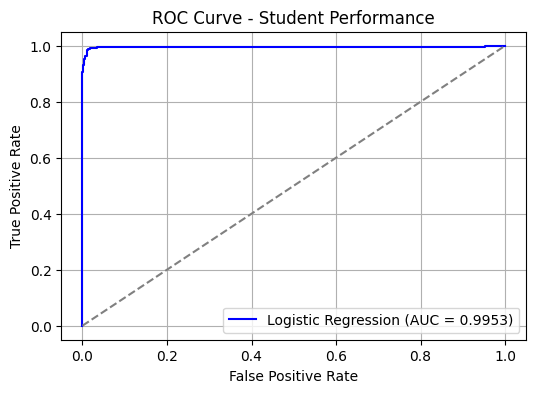


=== Task 5b: Threshold Sensitivity Table ===
Threshold  Precision  Recall  F1-score
     0.30     0.9037  0.9951    0.9472
     0.40     0.9399  0.9951    0.9667
     0.50     0.9697  0.9935    0.9815
     0.60     0.9869  0.9821    0.9845
     0.70     0.9915  0.9560    0.9734


In [8]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Task 5: Classification model — Logistic Regression

# Check class distribution in training labels
print("Class distribution before training:")
print(pd.Series(y_clf_train).value_counts())
print()

# Train Logistic Regression model with balanced class weights as per instructions
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train_scaled, y_clf_train)

# Predict class labels and probabilities on the test set
y_pred_clf = log_model.predict(X_test_scaled)
y_prob_clf = log_model.predict_proba(X_test_scaled)[:, 1]

# Compute and report confusion matrix and classification report
conf_matrix = confusion_matrix(y_clf_test, y_pred_clf)
auc_score = roc_auc_score(y_clf_test, y_prob_clf)

print("Confusion Matrix:\n", conf_matrix)
print()
print("Classification Report:\n", classification_report(y_clf_test, y_pred_clf))
print("ROC AUC Score:", round(auc_score, 4))
print()

# Compute and plot the ROC Curve using matplotlib
fpr, tpr, _ = roc_curve(y_clf_test, y_prob_clf)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', label=f'Logistic Regression (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Student Performance')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Task 5b: Decision-threshold sensitivity

# Vary decision threshold from 0.30 to 0.70 in steps of 0.10
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]
threshold_results = []

for t in thresholds:
    # Convert probabilities to class predictions based on current threshold
    y_pred_t = (y_prob_clf >= t).astype(int)

    # Compute precision, recall, and F1-score
    p = precision_score(y_clf_test, y_pred_t, zero_division=0)
    r = recall_score(y_clf_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_clf_test, y_pred_t, zero_division=0)

    threshold_results.append({
        'Threshold': f"{t:.2f}",
        'Precision': round(p, 4),
        'Recall': round(r, 4),
        'F1-score': round(f1, 4)
    })

# Print all five rows as a clean table (DataFrame)
df_thresholds = pd.DataFrame(threshold_results)
print("\n=== Task 5b: Threshold Sensitivity Table ===")
print(df_thresholds.to_string(index=False))

In [9]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Task 6: Regularization experiment on Logistic Regression

# Train a second logistic regression with strong regularization (C=0.01)
log_model_strong = LogisticRegression(max_iter=1000, class_weight='balanced', C=0.01)
log_model_strong.fit(X_train_scaled, y_clf_train)

# Predict probabilities for the strong regularization model
y_prob_strong = log_model_strong.predict_proba(X_test_scaled)[:, 1]
auc_strong = roc_auc_score(y_clf_test, y_prob_strong)

print("=== Task 6: Regularization Results ===")
print("Baseline Model (C=1.0) AUC :", round(auc_score, 4))
print("Strong Reg Model (C=0.01) AUC:", round(auc_strong, 4))
print()

# Task 7: Bootstrap confidence interval for AUC difference

# Set random seed for reproducibility
np.random.seed(42)

n_bootstraps = 500
auc_differences = []
y_clf_test_arr = np.array(y_clf_test)

# Run bootstrap iterations
for i in range(n_bootstraps):
    # Sample row indices with replacement
    indices = np.random.choice(len(y_clf_test_arr), size=len(y_clf_test_arr), replace=True)

    # Calculate AUC for both models on the bootstrap sample
    auc_baseline_boot = roc_auc_score(y_clf_test_arr[indices], y_prob_clf[indices])
    auc_strong_boot = roc_auc_score(y_clf_test_arr[indices], y_prob_strong[indices])

    # Compute the difference (C=1.0 minus C=0.01)
    auc_differences.append(auc_baseline_boot - auc_strong_boot)

# Compute mean, 2.5th and 97.5th percentiles
mean_diff = np.mean(auc_differences)
lower_bound = np.percentile(auc_differences, 2.5)
upper_bound = np.percentile(auc_differences, 97.5)

print("=== Task 7: Bootstrap Results ===")
print("Mean AUC Difference      :", round(mean_diff, 4))
print("2.5th Percentile (Lower) :", round(lower_bound, 4))
print("97.5th Percentile (Upper):", round(upper_bound, 4))

=== Task 6: Regularization Results ===
Baseline Model (C=1.0) AUC : 0.9953
Strong Reg Model (C=0.01) AUC: 0.9943

=== Task 7: Bootstrap Results ===
Mean AUC Difference      : 0.001
2.5th Percentile (Lower) : 0.0004
97.5th Percentile (Upper): 0.0017
